# Classical ML Essentials
### Thrive Plus · Advanced ML & AI

---

This workbook runs alongside the main notebook. Each exercise builds on something you just ran in the notebook — don't jump here before you've completed the corresponding section.

**How to use this:**
- Read the question carefully before writing any code
- Every exercise has starter code — fill in the `# YOUR CODE HERE` parts
- Run your cell, check the output, then read the hint if you're stuck
- Work through in order — later exercises assume earlier ones are done

---

## Contents
- [Part A: Exploring the Data](#pa)
- [Part B: Preprocessing](#pb)
- [Part C: Pipelines](#pc)
- [Part D: Random Forests](#pd)
- [Part E: Evaluation](#pe)
- [Part F: Mini-Project](#pf)

---

In [ ]:
# Run this first — same setup as the main notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# Recreate the AfriConnect dataset
n = 3000
churned = np.random.binomial(1, 0.27, n)
df = pd.DataFrame({
    "monthly_minutes":  np.where(churned, np.random.normal(90,  30, n), np.random.normal(180, 40, n)).clip(0),
    "data_gb":          np.where(churned, np.random.normal(1.2, 0.6, n), np.random.normal(4.5, 1.5, n)).clip(0),
    "topup_frequency":  np.where(churned, np.random.poisson(2, n), np.random.poisson(8, n)),
    "cs_contacts":      np.where(churned, np.random.poisson(4, n), np.random.poisson(1, n)),
    "tenure_months":    np.where(churned, np.random.exponential(8, n), np.random.exponential(30, n)).clip(1).astype(int),
    "contract_type":    np.random.choice(["prepaid", "postpaid", "enterprise"], n, p=[0.6, 0.3, 0.1]),
    "region":           np.random.choice(["North", "South", "East", "West"], n),
    "churned":          churned
})
df.loc[df.sample(frac=0.04).index, "data_gb"]     = np.nan
df.loc[df.sample(frac=0.02).index, "cs_contacts"] = np.nan

X = df.drop(columns=["churned"])
y = df["churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features     = ["monthly_minutes", "data_gb", "topup_frequency", "cs_contacts", "tenure_months"]
categorical_features = ["contract_type", "region"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Setup complete. Ready to work.")

Setup complete. Ready to work.


---
<a id='pa'></a>
## Part A: Exploring the Data

### A1 — Reading the data

Answer these questions by writing code and observing the output.

In [ ]:
df

,monthly_minutes,data_gb,topup_frequency,cs_contacts,tenure_months,contract_type,region,churned
0,204.550834,2.488110,9,1.0,5,postpaid,East,0
1,108.510178,0.865969,2,7.0,10,enterprise,South,1
2,110.507080,1.457257,3,3.0,1,prepaid,South,1
3,226.490384,6.554672,8,2.0,65,postpaid,South,0
4,158.416351,5.601639,4,1.0,37,prepaid,West,0
...,...,...,...,...,...,...,...,...
2995,140.245790,NaN,0,1.0,3,postpaid,South,1
2996,164.943098,3.474210,4,0.0,43,postpaid,East,0
2997,192.642715,1.761732,5,1.0,79,prepaid,East,0
2998,203.355321,6.085565,5,0.0,30,prepaid,East,0


In [ ]:
df['churned'].value_counts()

churned
0    2187
1     813
Name: count, dtype: int64

In [ ]:
# A1a: How many subscribers are in the full dataset?
total_subscribers = len(df)
print(f"Total subscribers: {total_subscribers}")
print()

# A1b: How many churned? How many stayed?
churned_count = df.churned.loc[df['churned'] == 1].count()
stayed_count  = df.churned.loc[df['churned'] == 0].count()

print(f"Churned: {churned_count}")
print(f"Stayed:  {stayed_count}")
print()

# A1c: Which column has the most missing values?
most_missing = df.isnull().sum().idxmax()

print(f"Most missing values in: {most_missing}")

Total subscribers: 3000

Churned: 813
Stayed:  2187

Most missing values in: data_gb


<details><summary>💡 Hint — click to expand</summary>

- `len(df)` gives the number of rows
- `df["churned"].sum()` counts 1s; `(df["churned"] == 0).sum()` counts 0s
- `df.isnull().sum().idxmax()` returns the column name with the most missing values

</details>

### A2 — Feature analysis

The plot you ran in the notebook showed distributions split by churn label. Now let's look at the *averages*.

In [ ]:
# A2: Calculate the mean of each numeric column, grouped by churned/stayed
# Expected output: a table with churned=0 and churned=1 as rows, numeric columns as columns

means_by_churn = df.groupby('churned')[numeric_features].mean() #(hint: df.groupby("churned")[numeric_features].mean())
print(means_by_churn.round(2))

print()
print("Which feature shows the biggest difference between churned and stayed?")

# Monthly_minutes shows the biggest difference between churned and stayed 

         monthly_minutes  data_gb  topup_frequency  cs_contacts  tenure_months
churned                                                                       
0                 179.51     4.53             7.94         1.01          28.74
1                  89.57     1.19             2.10         4.06           7.07

Which feature shows the biggest difference between churned and stayed?


<details><summary>💡 Hint</summary>

`df.groupby("churned")[numeric_features].mean()` — replace `numeric_features` with the list defined in setup.

</details>

### A3 — Creating a new feature

Sometimes the raw columns aren't the most useful form. A feature that combines or transforms existing columns can give the model extra signal.

In [ ]:
# A3a: Create a column called `minutes_per_topup`
# It should be monthly_minutes divided by topup_frequency
# Handle division by zero — if topup_frequency is 0, set minutes_per_topup to 0

df["minutes_per_topup"] = np.where(df['topup_frequency'] == 0, 0, df['monthly_minutes'] / df['topup_frequency'])

# A3b: What is the average minutes_per_topup for churned vs stayed subscribers?
print(df.groupby("churned")["minutes_per_topup"].mean().round(2))

# A3c: Does this new feature seem useful? Write a comment explaining why or why not.
# The average minutes per top_up for those who churned were more as compared to those who stayed

churned
0    26.58
1    45.85
Name: minutes_per_topup, dtype: float64


<details><summary>💡 Hint</summary>

For safe division (no division by zero):
```python
df["minutes_per_topup"] = df["monthly_minutes"] / df["topup_frequency"].replace(0, np.nan)
df["minutes_per_topup"] = df["minutes_per_topup"].fillna(0)
```
Or with `np.where`:
```python
df["minutes_per_topup"] = np.where(
    df["topup_frequency"] == 0, 0,
    df["monthly_minutes"] / df["topup_frequency"]
)
```

</details>

---
<a id='pb'></a>
## Part B: Preprocessing

### B1 — Why the split order matters

In [ ]:
# B1: This cell demonstrates data leakage — the wrong way to preprocess

# Wrong: fit the scaler on the FULL dataset (X), not just training
scaler_wrong = StandardScaler()
scaler_wrong.fit(X[["monthly_minutes"]])  # ← leaks test data into training

# Correct: fit the scaler on TRAINING DATA ONLY
scaler_correct = StandardScaler()
scaler_correct.fit(X_train[["monthly_minutes"]])  # ← safe

# Compare the learned means — they'll be slightly different
print(f"Mean learned from full dataset:  {scaler_wrong.mean_[0]:.4f}")
print(f"Mean learned from training only: {scaler_correct.mean_[0]:.4f}")
print()
print("Why are these different?")
# Write your explanation as a comment:
# The full dataset includes all rows, while training has only training rows.
# Because the test rows are included in the 'wrong' version, the statistics looks different
# 

Mean learned from full dataset:  155.1378
Mean learned from training only: 155.3298

Why are these different?


### B2 — Build a preprocessor from scratch

The main notebook gave you a complete preprocessor. Now build one yourself — for a different set of features.

In [ ]:
# B2: Build a preprocessor that handles just two features:
#   - cs_contacts (numeric) → impute with mean, then scale
#   - contract_type (categorical) → impute with most_frequent, then one-hot encode

mini_numeric = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy= 'mean' )),
    ("scaler",  StandardScaler())
])

mini_categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy= 'most_frequent' )),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

mini_preprocessor = ColumnTransformer(transformers=[
    ("num", mini_numeric,      ["cs_contacts"]),
    ("cat", mini_categorical,  ["contract_type"])
])

# Fit and transform
result = mini_preprocessor.fit_transform(X_train)
print(f"Output shape: {result.shape}")
print("Expected: (2400, 4)  →  1 scaled numeric + 3 one-hot contract_type columns")

Output shape: (2400, 4)
Expected: (2400, 4)  →  1 scaled numeric + 3 one-hot contract_type columns


<details><summary>💡 Hint</summary>

```python
SimpleImputer(strategy="mean")   # for numeric
SimpleImputer(strategy="most_frequent")  # for categorical
StandardScaler()  # for scaling
```

</details>

### B3 — fit_transform vs transform

In [ ]:
# B3: Complete the blanks — use fit_transform or transform correctly

fresh_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)
])

# Use fit_transform for the training set (learn AND apply)
X_train_proc = fresh_preprocessor.fit_transform(X_train)

# Use transform for the test set (apply only — use what was learned from training)
X_test_proc  = fresh_preprocessor.transform(X_test)

print(f"Training processed shape: {X_train_proc.shape}")
print(f"Test processed shape:     {X_test_proc.shape}")
print()
print("Why don't we call fit_transform on the test set?")
# Write your answer as a comment:
# the fit has been put on the training data to learn from it and the transform on the x_test is to apply the statistics it has learned from the training data to the testing/unseen data

Training processed shape: (2400, 12)
Test processed shape:     (600, 12)

Why don't we call fit_transform on the test set?


---
<a id='pc'></a>
## Part C: Pipelines

### C1 — Build a pipeline from scratch

In [ ]:
# C1: Build a complete pipeline using LogisticRegression
# It should have two steps: "preprocessor" and "classifier"
# max_iter=500 to ensure convergence

my_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor ),
    ("classifier",  LogisticRegression(max_iter= 500, random_state= 42))
])

# Fit it on training data
my_pipeline.fit(X_train, y_train)

# Predict on test data
my_preds = my_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, my_preds):.4f}")

Accuracy: 0.9950


### C2 — Compare three models fairly

Build three pipelines — one for each model — and collect their accuracy scores in a dictionary.

In [ ]:
# C2: Complete this loop — it should train three models and print their accuracy
# All three use the same preprocessor

models_to_try = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}  # store accuracy scores here

for model_name, model in models_to_try.items():
    # Build a pipeline for this model
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   model)
    ])

    # Fit
    pipe.fit(X_train,y_train)

    # Predict and store
    y_pred = pipe.predict(X_test)
    results[model_name] = round(accuracy_score(y_test, y_pred), 4)

print("Accuracy comparison:")
for name, score in results.items():
    print(f"  {name}: {score}")

Accuracy comparison:
  Logistic Regression: 0.995
  Decision Tree: 0.9833
  Random Forest: 0.9967


<details><summary>💡 Hint</summary>

Inside the loop:
- `"classifier", model` — use the variable `model`, not a hardcoded class name
- `pipe.fit(X_train, y_train)` — pass the original (un-preprocessed) data; the pipeline handles preprocessing
- `y_pred = pipe.predict(X_test)`

</details>

---
<a id='pd'></a>
## Part D: Random Forests

### D1 — Effect of n_estimators (number of trees)

How does accuracy change as you add more trees? Let's find out.

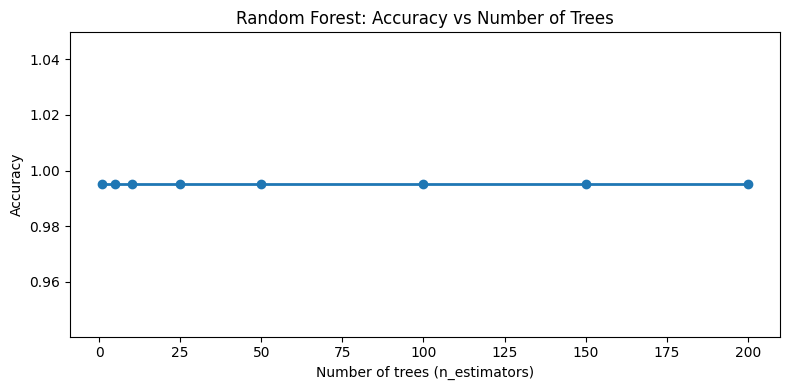

At what point do more trees stop helping?


In [ ]:
# D1: Train Random Forests with different numbers of trees and plot the result

tree_counts = [1, 5, 10, 25, 50, 100, 150, 200]
accuracies  = []

for n_trees in tree_counts:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   RandomForestClassifier(n_estimators=200, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot the result
plt.figure(figsize=(8, 4))
plt.plot(tree_counts, accuracies, marker="o", linewidth=2)
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees")
plt.tight_layout()
plt.show()

print("At what point do more trees stop helping?")
# Write your observation as a comment:
# At the point of approximately 5-10 number of trees the more trees does no help

### D2 — Effect of max_depth (tree depth)

A very deep tree will memorise the training data (overfitting). A very shallow tree won't learn enough (underfitting). Find the sweet spot.

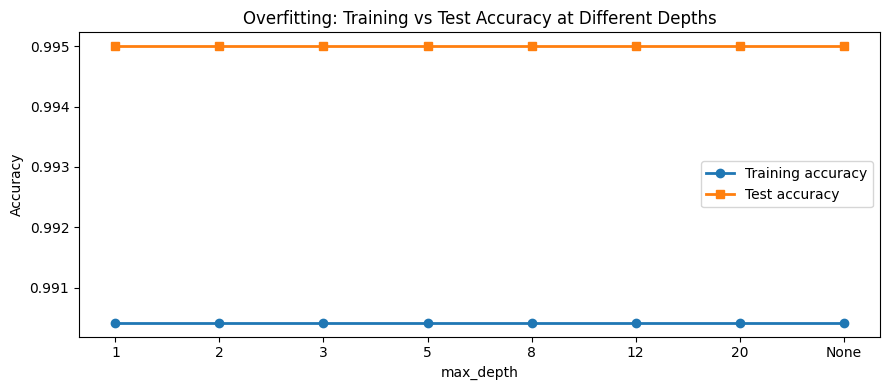

When does the gap between training and test accuracy grow largest? What does that indicate?


In [ ]:
# D2: Train Random Forests with different max_depth values
# For each depth, record BOTH the training accuracy and test accuracy

depths = [1, 2, 3, 5, 8, 12, 20, None]  # None = unlimited
train_accs = []
test_accs  = []

for depth in depths:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, pipe.predict(X_train))  # accuracy on training data
    test_acc  = accuracy_score(y_test,  pipe.predict(X_test))   # accuracy on test data

    train_accs.append(train_acc)
    test_accs.append(test_acc)

# Labels for the x-axis
depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(9, 4))
plt.plot(depth_labels, train_accs, marker="o", label="Training accuracy", linewidth=2)
plt.plot(depth_labels, test_accs,  marker="s", label="Test accuracy",     linewidth=2)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting: Training vs Test Accuracy at Different Depths")
plt.legend()
plt.tight_layout()
plt.show()

print("When does the gap between training and test accuracy grow largest? What does that indicate?")
# Write your observation:
# depth 1 Tr = 0.94 Te = 0.98
# depth 2 Tr = 0.98 Te = 0.991
# depth 3 Tr = 0.990 Te = 0.995

### D3 — Feature importance: interpreting the model

A Random Forest gives you a score for each feature indicating how useful it was for making predictions.

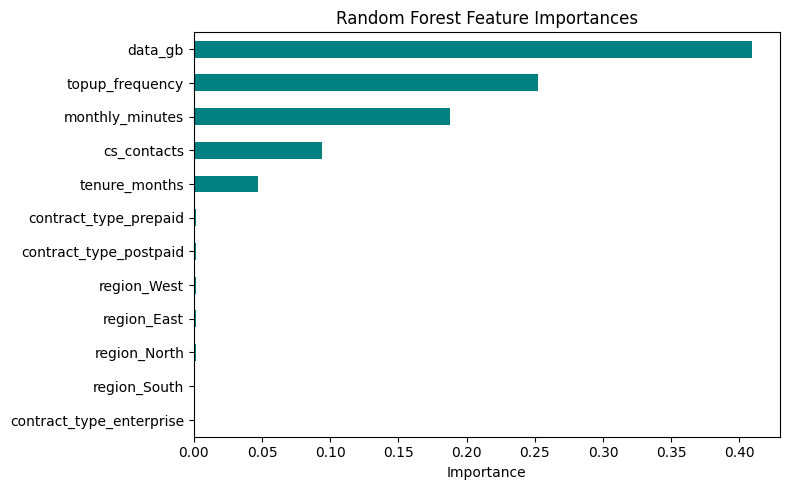

Top 3 features: ['data_gb', 'topup_frequency', 'monthly_minutes']

Which feature surprised you? Does its importance (or lack of importance) make business sense?


In [ ]:
# D3: Train a Random Forest, then extract and plot feature importances

# Step 1: Build and fit the pipeline
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])
rf_pipe.fit(X_train, y_train)

# Step 2: Extract the fitted model and preprocessor from the pipeline
rf_model     = rf_pipe.named_steps['classifier']  # hint: the step name you gave the classifier
fitted_prep  = rf_pipe.named_steps['preprocessor']  # hint: the step name you gave the preprocessor

# Step 3: Get the full list of feature names after one-hot encoding
cat_names = list(
    fitted_prep
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
all_names = numeric_features + cat_names

# Step 4: Pair each feature with its importance score and sort
importances = pd.Series(rf_model.feature_importances_, index=all_names).sort_values(ascending=True)

# Step 5: Plot (horizontal bar chart is easier to read with many features)
importances.plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 3 features:", importances.sort_values(ascending=False).head(3).index.tolist())
print()
print("Which feature surprised you? Does its importance (or lack of importance) make business sense?")
# Your observation:
# Data_gb is the most influential feature to predict churn
# Followed by topup_frequency, monthly_minutes, cs_contacts, tenure_months
# I thought monthly_minutes will be the most influential features

<details><summary>💡 Hint</summary>

The step names are what you put in the `("name", ...)` tuples when building the pipeline:
- `rf_pipe.named_steps["classifier"]` — the Random Forest
- `rf_pipe.named_steps["preprocessor"]` — the ColumnTransformer

</details>

---
<a id='pe'></a>
## Part E: Evaluation

### E1 — Reading a classification report

First, train a Random Forest pipeline to use for evaluation exercises.

In [ ]:
# Train the main pipeline we'll evaluate
main_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42))
])
main_rf.fit(X_train, y_train)
y_pred_main = main_rf.predict(X_test)

print(classification_report(y_test, y_pred_main, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00       437
     Churned       0.99      0.99      0.99       163

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



In [ ]:
# E1: Answer these questions about the classification report above

# E1a: What is the precision for the "Churned" class?
precision_churned = precision_score(y_test, y_pred_main)
print(f"Precision (Churned): {precision_churned:.4f}")
print("Meaning: of every 100 subscribers we flag as at-risk, about how many actually churn?")
print(f"→ About {round(precision_churned * 100)} subscribers")

print()

# E1b: What is the recall for the "Churned" class?
recall_churned = recall_score(y_test, y_pred_main)
print(f"Recall (Churned): {recall_churned:.4f}")
print("Meaning: of every 100 actual churners, about how many does the model catch?")
print(f"→ About {round(recall_churned * 100)} subscribers")

print()
print("For AfriConnect, is precision or recall more important? Why?")
# Your answer:
# Recall is more important as it help us avoid missing those who churn

Precision (Churned): 0.9938
Meaning: of every 100 subscribers we flag as at-risk, about how many actually churn?
→ About 99 subscribers

Recall (Churned): 0.9877
Meaning: of every 100 actual churners, about how many does the model catch?
→ About 99 subscribers

For AfriConnect, is precision or recall more important? Why?


### E2 — Adjusting the threshold

What happens to precision and recall when you lower the classification threshold?

In [ ]:
# E2: Compare three thresholds: 0.3, 0.5, 0.7
# For each: compute precision, recall, and F1 for the churned class

y_proba = main_rf.predict_proba(X_test)[:, 1]  # probability of churning

thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)  # flag as churner if probability >= threshold

    p = precision_score(y_test, y_pred_t) # precision_score
    r = recall_score(y_test, y_pred_t) # recall_score
    f = f1_score(y_test, y_pred_t) # f1_score

    print(f"Threshold = {t}  →  Precision: {p:.3f}  |  Recall: {r:.3f}  |  F1: {f:.3f}")

print()
print("As the threshold decreases, what happens to precision? What happens to recall?")
# Your observation:
# As threshold decreases, precision decreases and recall increases

Threshold = 0.3  →  Precision: 0.942  |  Recall: 1.000  |  F1: 0.970
Threshold = 0.5  →  Precision: 0.994  |  Recall: 0.988  |  F1: 0.991
Threshold = 0.7  →  Precision: 1.000  |  Recall: 0.951  |  F1: 0.975

As the threshold decreases, what happens to precision? What happens to recall?


<details><summary>💡 Hint</summary>

```python
precision_score(y_test, y_pred_t)
recall_score(y_test, y_pred_t)
f1_score(y_test, y_pred_t)
```

</details>

### E3 — Cross-validation

In [ ]:
# E3: Run 5-fold cross-validation on the Random Forest pipeline
# Use roc_auc as the scoring metric
# Note: always cross-validate on the TRAINING set, not the test set

cv_scores = cross_val_score(
    rf_pipe, # the pipeline
    X_train, # X_train
    y_train, # y_train
    cv=5,
    scoring="roc_auc"
)

print(f"CV scores: {cv_scores.round(4)}")
print(f"Mean:      {cv_scores.mean():.4f}")
print(f"Std:       {cv_scores.std():.4f}")
print()
print("Is the std low enough that you trust these scores? What would a high std tell you?")
# Your answer:
# A low standard deviation mean the model is stable and consistent
# A high standard deviation mean the model depend heavily on which rows it sees

CV scores: [0.9998 0.9981 0.9995 0.9996 1.    ]
Mean:      0.9994
Std:       0.0007

Is the std low enough that you trust these scores? What would a high std tell you?


---
<a id='pf'></a>
## Part F: Mini-Project

### The brief

Build a complete, GitHub-ready ML project on a tabular dataset. This is the portfolio piece for M1.

**Choose a dataset** (or use the AfriConnect data from this session):

| Dataset | Task | How to load |
|---|---|---|
| Telco Customer Churn (IBM) | Binary classification | `pd.read_csv(url)` — see below |
| Heart Disease (UCI) | Binary classification | `from sklearn.datasets import fetch_openml; fetch_openml(name='heart-disease')` |
| Credit Risk (UCI) | Binary classification | `fetch_openml(name='credit-g')` |
| Diabetes (Pima) | Binary classification | `fetch_openml(name='diabetes')` |

---

### F1 — Load and explore your chosen dataset

In [ ]:
# F1: Load your dataset and run basic EDA
# Uncomment one option below:

 #Option A: Telco churn (IBM)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_project = pd.read_csv(url)

# Option B: UCI Heart Disease
# from sklearn.datasets import fetch_openml
# data = fetch_openml(name="heart-disease", as_frame=True)
# df_project = data.frame

# Option C: Use the AfriConnect data from this session
# df_project = df.copy()

# ---
# Once loaded, run your EDA:
df_project.head()
print(df_project.shape)
print(df_project.info())
print(df_project.isnull().sum())
print(df_project["Churn"].value_counts(normalize=True))

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [ ]:
df_project.head(5)
#df_project['SeniorCitizen'].value_counts()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
cat_cols= df_project.select_dtypes(include= ['object']).columns.to_list()
print(cat_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### F2 — Build the pipeline and train

In [ ]:
# F2: Full pipeline — fill in the blanks

# 1. Define your features and target
TARGET = ['Churn']            
PROJECT_NUMERIC      = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
PROJECT_CATEGORICAL  = ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

# 2. Split
X_proj = df_project.drop(columns=['Churn'])
y_proj = df_project['Churn']

X_proj_train, X_proj_test, y_proj_train, y_proj_test = train_test_split(
    X_proj, y_proj, test_size=0.2, random_state=42, stratify=y_proj
)

# 3. Preprocessor
proj_numeric_transformer     = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
proj_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
proj_preprocessor = ColumnTransformer(transformers=[
    ("num", proj_numeric_transformer,     PROJECT_NUMERIC),
    ("cat", proj_categorical_transformer, PROJECT_CATEGORICAL)
])

# 4. Full pipeline
proj_pipeline = Pipeline(steps=[
    ("preprocessor", proj_preprocessor),
    ("classifier",   RandomForestClassifier(n_estimators=100, random_state=42))
])

proj_pipeline.fit(X_proj_train, y_proj_train)
y_proj_pred = proj_pipeline.predict(X_proj_test)

print(f"Accuracy: {accuracy_score(y_proj_test, y_proj_pred):.4f}")
print()
print(classification_report(y_proj_test, y_proj_pred))

Accuracy: 0.7949

              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1035
         Yes       0.65      0.48      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### F3 — Evaluate and document

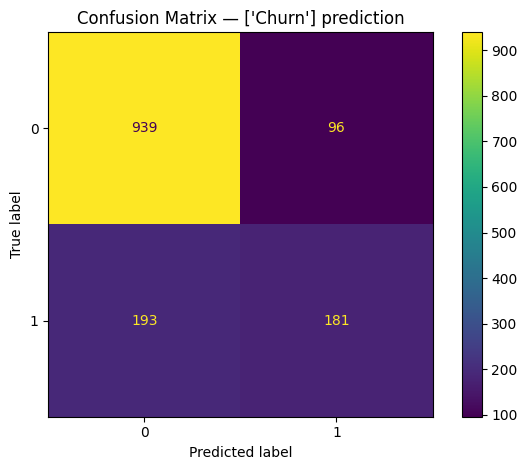

In [ ]:
# F3a: Plot the confusion matrix
cm = confusion_matrix(y_proj_test, y_proj_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix — {TARGET} prediction")
plt.tight_layout()
plt.show()

In [ ]:
# F3b: Calculate and print AUC-ROC
y_proj_proba = proj_pipeline.predict_proba(X_proj_test)[:, 1]
auc = roc_auc_score(y_proj_test, y_proj_proba)
print(f"AUC-ROC: {auc:.4f}")

# F3c: Run 5-fold cross-validation
cv = cross_val_score(proj_pipeline, X_proj_train, y_proj_train, cv=5, scoring="roc_auc")
print(f"CV AUC:  {cv.mean():.4f} ± {cv.std():.4f}")

AUC-ROC: 0.8208
CV AUC:  0.8305 ± 0.0115


In [ ]:
# F3d: Write your 3-sentence plain-language summary here
summary = "This model does well in predicting data point that actually stayed and a few of the data points that churn as seen in the precision and recall figure this may be because of the imbalance in the target column. It does quite well using the metrics of the  Accuracy score and the AUC-ROC score. The model is doint quite well , but will still go under more training as currently it has low false alarms but it seems it is missing quite a number of clients that churned."
#Write 3 sentences here:
#1. What does this model do and what data does it use?
#2. How well does it perform, and by which metrics?
#3. What would you tell the business team about the results?

print(summary)

This model does well in predicting data point that actually stayed and a few of the data points that churn as seen in the precision and recall figure this may be because of the imbalance in the target column. It does quite well using the metrics of the  Accuracy score and the AUC-ROC score. The model is doint quite well , but will still go under more training as currently it has low false alarms but it seems it is missing quite a number of clients that churned.
